In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
ROOT = Path.cwd().parents[1]



## Alpha for decaying the prior over arriving target context

By convention, the mixture looks like this:
mixture_logits = alpha * target_logits + (1 - alpha) * weighted_related

i.e. we probably want small $\alpha$ values for small current task context amounts, so that we rely more on the prior then the inference on the small current context.

Below an example for exponential decay in alpha

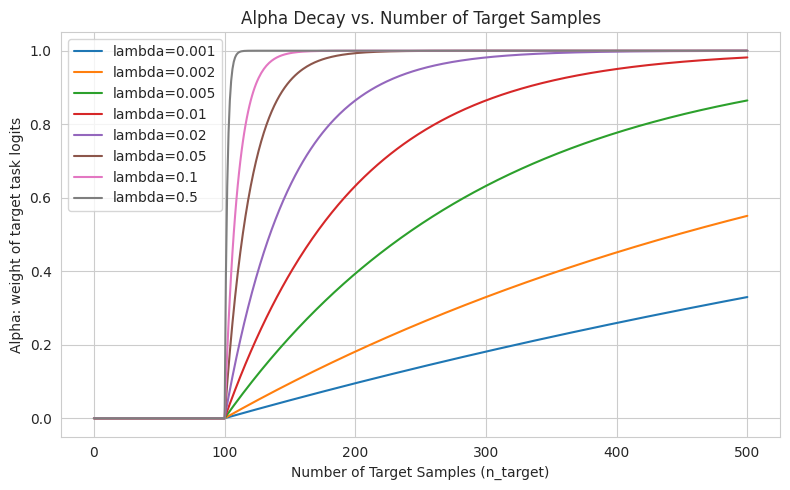

In [2]:
from src.model.mixture.decay import constant_exponential

n_targets = np.arange(0, 501, 1)  # From 0 to 200 data points
lambdas = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5]
shift=100

plt.figure(figsize=(8, 5))
for lambda_ in lambdas:
    alphas = constant_exponential(n_targets, lambda_, constant=shift)
    plt.plot(n_targets, alphas, label=f'lambda={lambda_}')

plt.title('Alpha Decay vs. Number of Target Samples')
plt.xlabel('Number of Target Samples (n_target)')
plt.ylabel('Alpha: weight of target task logits')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Plotting Local (Debug) PPD Mixture results

In [6]:
FILE_PATH = ROOT / 'output/base/999_960c3f9_pfn_mixture_lcbench_seed_1'

/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


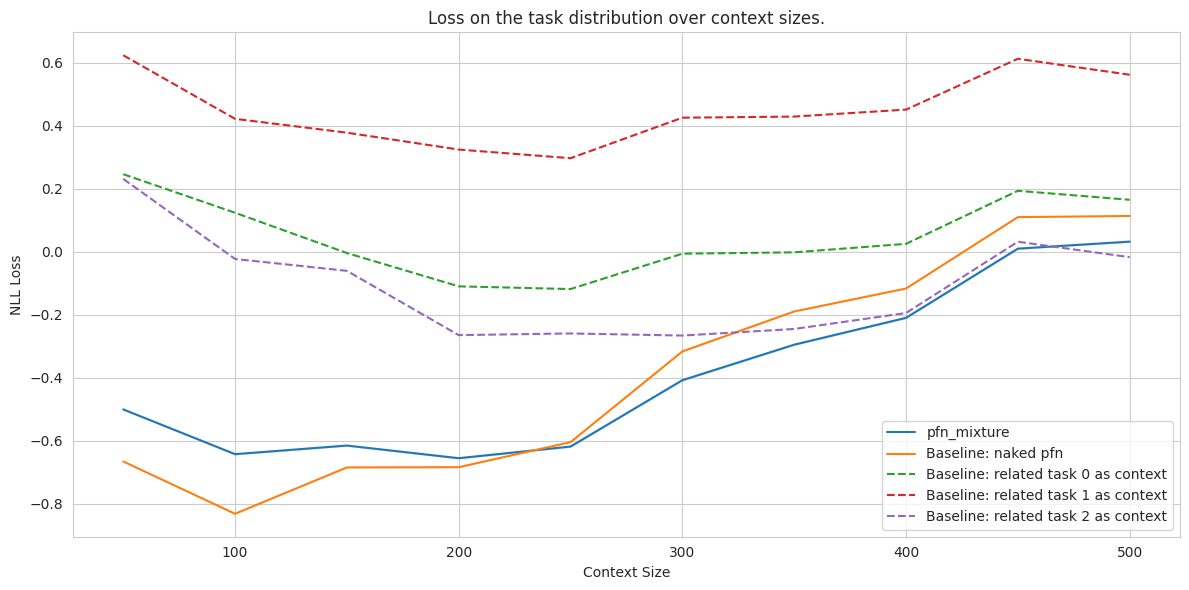

In [7]:
import matplotlib.pyplot as plt
from src.utils.filelogger import BufferedFileLogger


file_name = 'results.csv'

logger = BufferedFileLogger(
    file_name=file_name,
    file_path=FILE_PATH,
    header=('metric', 'value', 'global_step', 'context_size', 'task')
)

ax = logger.plot_scalar_curve(
    metric='pfn_mixture',
    title="PFN Mixture",
    x='context_size',
    plot=False,
)

ax = logger.plot_scalar_curve(
    metric='Baseline: naked pfn',
    title="Baseline: Naked PFN",
    x='context_size',
    plot=False,
    ax=ax
)

df = logger.dataframe
gtapprox = df[df['metric'] == 'Baseline: approx. conditioning on complete related']

import seaborn as sns

group = gtapprox.groupby(by='task')
for task, group in group:
    sns.lineplot(
        group, x='context_size', y='value', ax=ax,
        label=f'Baseline: related task {task} as context',
        linestyle='--'
    )

# when we only look at the current context to predict the
# ax.hlines(y=df[df.metric == 'Baseline: complete target_task_x as context']['value'],
#           xmax=max(df.context_size), xmin=min(df.context_size),
#           label=f'Baseline: complete target_task_x as context', )

ax.set_xlabel("Context Size")
ax.set_ylabel("NLL Loss")
ax.set_title("Loss on the task distribution over context sizes.")
plt.show()



The expectation: Considering that the nakedPFN needs roughly 200 steps to get to a state, where our prior is in terms of nll loss on the current task, we hope that with a PFN mixture, that places a lot of weight (low alpha = no weight on the current task's logits) on the prior for the initial 200 steps, we should get predictions that are initially better. Since additional context arrives and in reality, the prior likely is not the same as the data from the task distribution, we will want to decay its influence over time.

But at least in the same BNN task, different budget allocation, it seems like only the latest tokens (somewhere in the range of 400-500 tokens) gives us better and relevant data for the current task; i.e. the prior is very strong here and basically the convergence lower bound.

## Plotting local (debug) distillation runs

In [4]:
file_path = ROOT / 'output/base/999_8b4ca2d_distill_sanity_same_seed_42'

In [5]:
## Plotting Local (Debug) PPD Mixture results
import matplotlib.pyplot as plt
from src.utils.filelogger import BufferedFileLogger


file_name = 'results.csv'

logger = BufferedFileLogger(
    file_name=file_name,
    file_path=file_path,
    header=('metric', 'value', 'global_step', 'context_size', 'task')
)

In [9]:
df = logger.dataframe
df

,metric,value,global_step,context_size,task
0,train_loss,-3.101156,0.0,100,-1
1,train_loss,-3.025523,0.0,100,-1
2,nll_distilled_reconstruction,-3.143289,0.0,0,0
3,nll_distilled_reconstruction,-3.257851,0.0,0,1
4,nll_distilled_predictive,-0.383023,0.0,0,0
...,...,...,...,...,...
666,x_init context (no-distillation),-1.353595,NaN,400,1
667,x_init context (no-distillation),-1.606410,NaN,450,0
668,x_init context (no-distillation),-1.869388,NaN,450,1
669,x_init context (no-distillation),-1.524278,NaN,500,0


In [8]:
df['metric'].unique()

array(['train_loss', 'nll_distilled_reconstruction',
       'nll_distilled_predictive', 'distill',
       'Baseline: complete target_task_x as context',
       'Baseline: approx. conditioning on complete related',
       'Baseline: naked pfn', 'x_init context (no-distillation)'],
      dtype=object)

# Performance during training (Global Step):
* nll_distilled_reconstruction: The idea is, that we try to predict the y query values for x_query, provided we only have the distillation vectors for each task on its own holdout data
* nll_distilled_predictive:  Here, we try to use the distilled vectors of each task to predict for the target task; i.e. check the generalization capability

/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


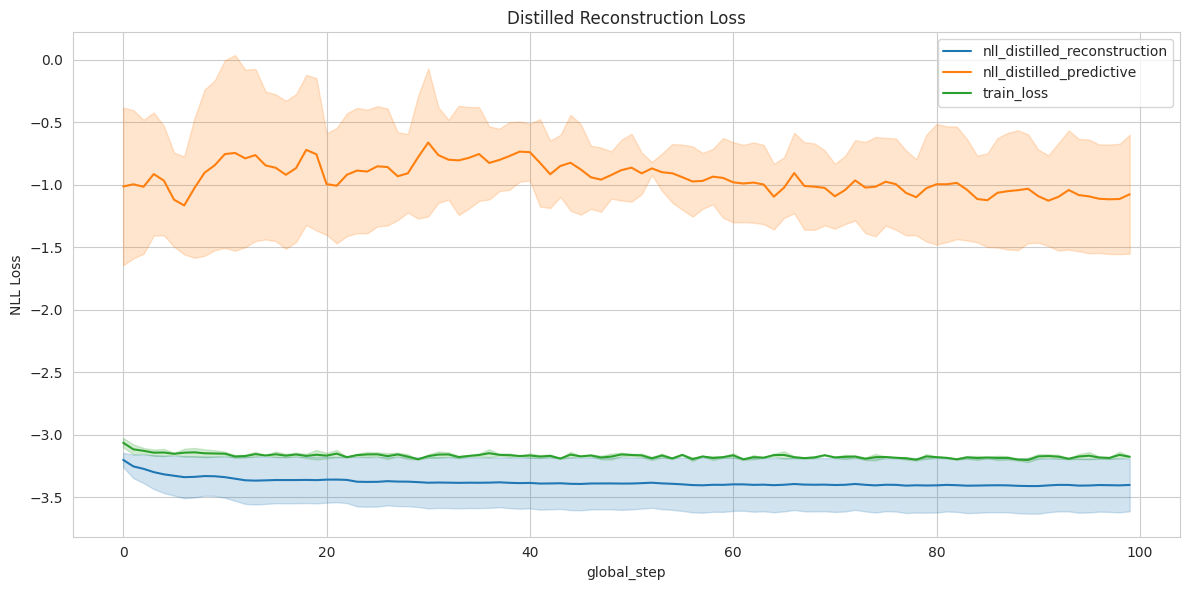

In [12]:

ax = logger.plot_scalar_curve(
    metric="nll_distilled_reconstruction",
    title="Distilled Reconstruction Loss",
    x='global_step',
    plot=False
)

ax = logger.plot_scalar_curve(
    metric="nll_distilled_predictive",
    title="Distilled Predictive Loss",
    x='global_step',
    plot=False,
    ax=ax
)
ax = logger.plot_scalar_curve(
    metric="train_loss",
    title="Distilled Training Loss",
    x='global_step',
    plot=False,
    ax=ax
)

ax.set_xlabel("global_step")
ax.set_ylabel("NLL Loss")
ax.set_title("Distilled Reconstruction Loss")
plt.show()


# PFN over context sizes
Now we have a look at the actual performance on the target task over context_sizes

/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/ruhkopf/PycharmProjects/ExperiencedFT-PFNs/src/utils/filelogger.py:151: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


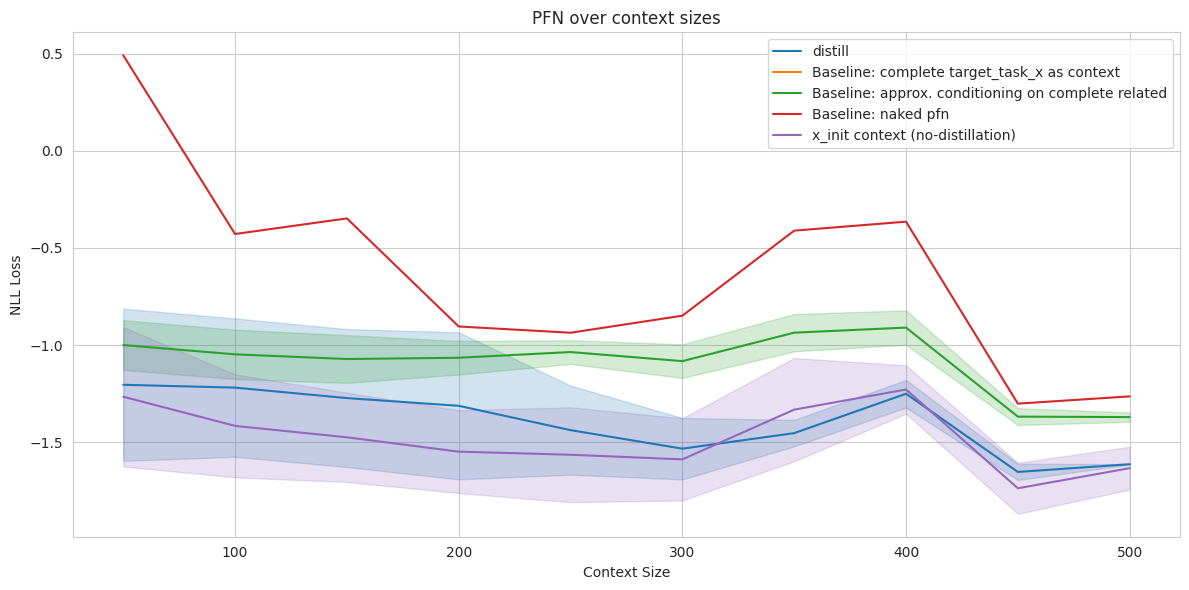

In [15]:
keys = ['distill',
       'Baseline: complete target_task_x as context',
       'Baseline: approx. conditioning on complete related',
       'Baseline: naked pfn', 'x_init context (no-distillation)']

ax = None
for key in keys:
    ax = logger.plot_scalar_curve(
        metric=key,
        title=f"PFN over context sizes",
        x='context_size',
        plot=False,
        ax=ax,
    )
ax.set_xlabel("Context Size")
ax.set_ylabel("NLL Loss")
ax.set_title(f"PFN over context sizes")
plt.show()